# PARSE — Topic Modelling on MSF Conflict-Zone Health Reports

**Data source:** msf.org public reports, scraped directly. No API key needed.

No patient data is used at any stage.

In [1]:
!pip install requests beautifulsoup4 scikit-learn pandas numpy matplotlib seaborn wordcloud --quiet

## 1. Scrape MSF reports from conflict countries

In [8]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import re

HEADERS = {
    'User-Agent': 'PARSE-Project/1.0 (Academic research, Université Paris Cité)'
}

# MSF country pages — each lists recent articles
# Format: https://www.msf.org/COUNTRY
COUNTRIES = {
    'sudan': 'Sudan',
    'palestine': 'Palestine',
    'democratic-republic-congo': 'DRC',
    'yemen': 'Yemen',
    'syria': 'Syria',
    'ukraine': 'Ukraine',
    'myanmar': 'Myanmar',
    'haiti': 'Haiti',
    'south-sudan': 'South Sudan',
    'afghanistan': 'Afghanistan',
    'somalia': 'Somalia',
    'lebanon': 'Lebanon'
}

def get_article_links(country_slug, max_pages=3):
    """Get article URLs from an MSF country page."""
    links = []
    for page in range(max_pages):
        url = f'https://www.msf.org/{country_slug}'
        if page > 0:
            url += f'?page={page}'
        try:
            resp = requests.get(url, headers=HEADERS, timeout=15)
            if resp.status_code != 200:
                break
            soup = BeautifulSoup(resp.text, 'html.parser')
            # Find article links — MSF uses <a> tags with href starting with /
            for a in soup.find_all('a', href=True):
                href = a['href']
                # Article links are like /sudan-xxx-xxx or /article-title
                if (href.startswith('/') and
                    not href.startswith('/#') and
                    not href.startswith('/search') and
                    not href.startswith('/latest') and
                    not href.startswith('/topics') and
                    not href.startswith('/where') and
                    not href.startswith('/who') and
                    not href.startswith('/what') and
                    not href.startswith('/reports') and
                    not href.startswith('/donate') and
                    not href.startswith('/contact') and
                    len(href) > 10 and
                    href.count('/') == 1):
                    full_url = f'https://www.msf.org{href}'
                    if full_url not in links:
                        links.append(full_url)
            time.sleep(1)
        except Exception as e:
            print(f'  Page {page} error: {e}')
            break
    return links

def get_article_text(url):
    """Extract article body text from an MSF article page."""
    try:
        resp = requests.get(url, headers=HEADERS, timeout=15)
        if resp.status_code != 200:
            return None, None
        soup = BeautifulSoup(resp.text, 'html.parser')

        # Title
        title_tag = soup.find('h1')
        title = title_tag.get_text(strip=True) if title_tag else ''

        # Body — use #main-content, the only selector that works on MSF's Drupal site
        main = soup.select_one('#main-content')
        if not main:
            main = soup.select_one('.content') or soup.find('main')

        if not main:
            return title, None

        # Get all paragraphs from main content, skip short nav items
        paras = []
        for p in main.find_all('p'):
            text = p.get_text(strip=True)
            if len(text) > 50:
                paras.append(text)

        body = ' '.join(paras)
        return title, body
    except Exception as e:
        return None, None

print('Ready to scrape MSF reports.')

Ready to scrape MSF reports.


In [6]:
def get_article_text(url):
    """Extract article body text from an MSF article page."""
    try:
        resp = requests.get(url, headers=HEADERS, timeout=15)
        if resp.status_code != 200:
            return None, None
        soup = BeautifulSoup(resp.text, 'html.parser')

        # Title
        title_tag = soup.find('h1')
        title = title_tag.get_text(strip=True) if title_tag else ''

        # Body — use #main-content, the only selector that works on MSF's Drupal site
        main = soup.select_one('#main-content')
        if not main:
            main = soup.select_one('.content') or soup.find('main')

        if not main:
            return title, None

        # Get all paragraphs from main content, skip short nav items
        paras = []
        for p in main.find_all('p'):
            text = p.get_text(strip=True)
            if len(text) > 50:
                paras.append(text)

        body = ' '.join(paras)
        return title, body
    except Exception as e:
        return None, None

In [9]:
# Step 1: Collect article URLs from each country page
all_links = {}

for slug, name in COUNTRIES.items():
    print(f'{name}...', end=' ')
    links = get_article_links(slug, max_pages=3)
    all_links[name] = links
    print(f'{len(links)} articles found')

total = sum(len(v) for v in all_links.values())
print(f'\nTotal unique article URLs: {total}')

Sudan... 46 articles found
Palestine... 44 articles found
DRC... 43 articles found
Yemen... 50 articles found
Syria... 55 articles found
Ukraine... 34 articles found
Myanmar... 34 articles found
Haiti... 50 articles found
South Sudan... 42 articles found
Afghanistan... 55 articles found
Somalia... 32 articles found
Lebanon... 42 articles found

Total unique article URLs: 527


In [10]:
# tests one known article to diagnose the extraction problem

import requests
from bs4 import BeautifulSoup

HEADERS = {'User-Agent': 'PARSE-Project/1.0 (Academic research)'}

test_url = 'https://www.msf.org/addressing-myriad-medical-needs-amidst-conflict-sudan'
resp = requests.get(test_url, headers=HEADERS, timeout=15)
print(f"Status: {resp.status_code}")
print(f"Content length: {len(resp.text)} chars")

soup = BeautifulSoup(resp.text, 'html.parser')

# Try every possible selector
print("\n--- Testing selectors ---")
for selector in ['article', 'main', '.node__content', '.field--name-body',
                 '.text-long', '[property="schema:text"]', '.paragraph',
                 '.content', '#main-content']:
    found = soup.select(selector)
    if found:
        text = found[0].get_text(strip=True)[:200]
        print(f"  {selector}: FOUND ({len(found)} elements) -> {text[:100]}...")
    else:
        print(f"  {selector}: not found")

# Fallback: just get all substantial paragraphs
print("\n--- All <p> tags with 50+ chars ---")
paras = [p.get_text(strip=True) for p in soup.find_all('p') if len(p.get_text(strip=True)) > 50]
print(f"  Found {len(paras)} substantial paragraphs")
if paras:
    print(f"  First: {paras[0][:150]}...")
    print(f"  Total text: {sum(len(p) for p in paras)} chars")

Status: 200
Content length: 242421 chars

--- Testing selectors ---
  article: FOUND (47 elements) -> Who We AreLearn about our mission, our charter and principles, and who we are.Learn moreWho We Are...
  main: FOUND (1 elements) -> Addressing myriad medical needs amidst conflict in SudanPatients sit in the corridor of the MSF-supp...
  .node__content: not found
  .field--name-body: not found
  .text-long: not found
  [property="schema:text"]: not found
  .paragraph: not found
  .content: FOUND (1 elements) -> Addressing myriad medical needs amidst conflict in SudanPatients sit in the corridor of the MSF-supp...
  #main-content: FOUND (1 elements) -> Dr Mohammad Bashir, Médecins Sans Frontières (MSF) deputy medical coordinator, reflects on his exper...

--- All <p> tags with 50+ chars ---
  Found 45 substantial paragraphs
  First: Learn about our mission, our charter and principles, and who we are....
  Total text: 10711 chars


In [11]:
# Step 2: Fetch full text of each article
rows = []
total_fetched = 0

for country, links in all_links.items():
    print(f'\nFetching {country} ({len(links)} articles)...')
    for i, url in enumerate(links):
        if i % 10 == 0 and i > 0:
            print(f'  {i}/{len(links)}')
        title, body = get_article_text(url)
        if body and len(body) > 200:
            rows.append({
                'country': country,
                'title': title or '',
                'body': body,
                'url': url
            })
            total_fetched += 1
        time.sleep(0.5)  # be polite

df = pd.DataFrame(rows)
print(f'\nTotal documents with body text: {len(df)}')
print(f'\nPer country:')
print(df['country'].value_counts())


Fetching Sudan (46 articles)...
  10/46
  20/46
  30/46
  40/46

Fetching Palestine (44 articles)...
  10/44
  20/44
  30/44
  40/44

Fetching DRC (43 articles)...
  10/43
  20/43
  30/43
  40/43

Fetching Yemen (50 articles)...
  10/50
  20/50
  30/50
  40/50

Fetching Syria (55 articles)...
  10/55
  20/55
  30/55
  40/55
  50/55

Fetching Ukraine (34 articles)...
  10/34
  20/34
  30/34

Fetching Myanmar (34 articles)...
  10/34
  20/34
  30/34

Fetching Haiti (50 articles)...
  10/50
  20/50
  30/50
  40/50

Fetching South Sudan (42 articles)...
  10/42
  20/42
  30/42
  40/42

Fetching Afghanistan (55 articles)...
  10/55
  20/55
  30/55
  40/55
  50/55

Fetching Somalia (32 articles)...
  10/32
  20/32
  30/32

Fetching Lebanon (42 articles)...
  10/42
  20/42
  30/42
  40/42

Total documents with body text: 511

Per country:
country
Afghanistan    53
Syria          53
Haiti          49
Yemen          48
Sudan          45
Palestine      43
DRC            42
South Sudan    41
Leb

In [12]:
# Save — so you never need to scrape again
df.to_csv('msf_conflict_reports_scraped.csv', index=False)
print(f'Saved {len(df)} reports to msf_conflict_reports_scraped.csv')
print(f'Average body length: {df["body"].str.len().mean():.0f} chars')

Saved 511 reports to msf_conflict_reports_scraped.csv
Average body length: 7024 chars


## 2. Clean text

In [13]:
# If reloading from saved file:
# df = pd.read_csv('msf_conflict_reports_scraped.csv')

def clean(text):
    text = re.sub(r'http\S+', ' ', text)
    text = re.sub(r'[^a-zA-ZÀ-ÿ\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean'] = df['body'].apply(clean)
df = df[df['clean'].str.split().str.len() > 50].reset_index(drop=True)
print(f'Documents after cleaning: {len(df)}')

Documents after cleaning: 507


## 3. LDA topic modelling

In [14]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

STOP = [
    'the','and','for','that','with','are','was','has','have','been','from',
    'this','will','their','they','who','also','more','than','its','but',
    'not','our','can','all','which','about','were','said','one','would',
    'there','what','other','into','when','over','most','after','some',
    'them','being','between','had','many','very','could','should','while',
    'just','those','because','these','how','where','only','such','need',
    'well','still','new','now','year','years','since','first','two',
    'three','around','back','even','get','make','way','time','day',
    'les','des','est','dans','une','que','pour','qui','par','sur','pas',
    'sont','plus','ont','avec','nous','ses','aux','ces','cette','mais',
    'comme','leur','tout','fait','peut','elle','entre','sans','aussi',
    'msf','médecins','frontières','doctors','without','borders',
    'humanitarian','international','people','country','says','according',
    'organisation','organization','teams','team','staff','area','areas'
]

vec = CountVectorizer(max_df=0.85, min_df=3, stop_words=STOP,
                      max_features=5000, ngram_range=(1,2))
dtm = vec.fit_transform(df['clean'])
words = vec.get_feature_names_out()
print(f'Matrix: {dtm.shape}')

N = 10
lda = LatentDirichletAllocation(n_components=N, random_state=42,
                                max_iter=30, learning_method='online')
lda.fit(dtm)

print(f'\n{N} Topics:\n')
for i, t in enumerate(lda.components_):
    top = [words[j] for j in t.argsort()[:-12:-1]]
    print(f'Topic {i}: {", ".join(top)}\n')

df['topic'] = lda.transform(dtm).argmax(axis=1)

Matrix: (507, 5000)

10 Topics:

Topic 0: tb, treatment, health, care, diagnosis, ministry, ministry of, prevention, of health, tb care, worked

Topic 1: el, fasher, el fasher, darfur, tawila, law, rsf, in el, report, terms, guide

Topic 2: as, health, patients, hospital, at, care, it, healthcare, an, or, be

Topic 3: care, health, as, gaza, mental, israeli, mental health, al, services, at, healthcare

Topic 4: or, health, as, care, drc, response, kivu, assistance, affected, outbreak, ebola

Topic 5: president, as, board, members, general, assembly, dr, he, associations, his, abdelmoneim

Topic 6: base, manager working, eastern drc, kivu, south kivu, north kivu, drc, health, kivu south, as, de

Topic 7: your, data, you, information, personal, personal data, us, as, your personal, use, or

Topic 8: as, de, la, et, support, role, you, an, at, information, health

Topic 9: de, la, et, support, you, role, as, operational, le, du, en



## 4. PARSE bias analysis

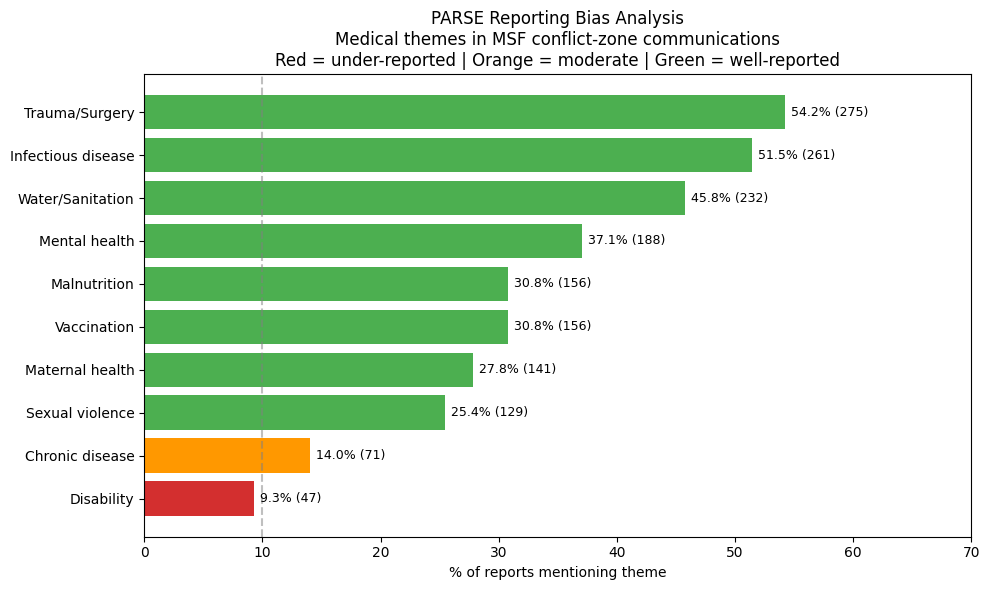

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

THEMES = {
    'Trauma/Surgery': ['trauma','surgery','surgical','wound','injury','shelling','bomb','blast','fracture'],
    'Infectious disease': ['cholera','malaria','measles','hepatitis','tuberculosis','dengue','epidemic','outbreak'],
    'Maternal health': ['maternal','pregnancy','childbirth','obstetric','midwife','antenatal','neonatal','newborn','birth'],
    'Malnutrition': ['malnutrition','nutrition','stunting','wasting','feeding','malnourished','therapeutic food'],
    'Mental health': ['mental health','psychological','psychosocial','counseling','counselling','ptsd','anxiety','depression'],
    'Sexual violence': ['sexual violence','rape','gender based violence','gbv','sexual assault','sexual abuse'],
    'Chronic disease': ['chronic','diabetes','hypertension','cancer','cardiovascular','noncommunicable','ncd'],
    'Vaccination': ['vaccination','vaccine','immunization','immunisation','campaign'],
    'Water/Sanitation': ['water','sanitation','hygiene','wash','contamination','waterborne','clean water'],
    'Disability': ['disability','disabled','prosthetic','rehabilitation','physiotherapy','ampute']
}

low = df['clean'].str.lower()
tc = {}
for theme, kw in THEMES.items():
    tc[theme] = low.str.contains('|'.join(kw)).sum()

tdf = pd.DataFrame({'Theme': tc.keys(), 'N': tc.values(),
                     'Pct': [v/len(df)*100 for v in tc.values()]}
                    ).sort_values('N', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#d32f2f' if p<10 else '#ff9800' if p<25 else '#4caf50' for p in tdf['Pct']]
ax.barh(tdf['Theme'], tdf['Pct'], color=colors)
ax.set_xlabel('% of reports mentioning theme')
ax.set_title('PARSE Reporting Bias Analysis\nMedical themes in MSF conflict-zone communications\n'
             'Red = under-reported | Orange = moderate | Green = well-reported')
ax.axvline(x=10, color='gray', linestyle='--', alpha=0.5)
ax.set_xlim(right=70) # Set x-axis limit to 70
for i, (p, n) in enumerate(zip(tdf['Pct'], tdf['N'])):
    ax.text(p+0.5, i, f'{p:.1f}% ({n})', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('parse_reporting_bias.png', dpi=150, bbox_inches='tight')
plt.show()

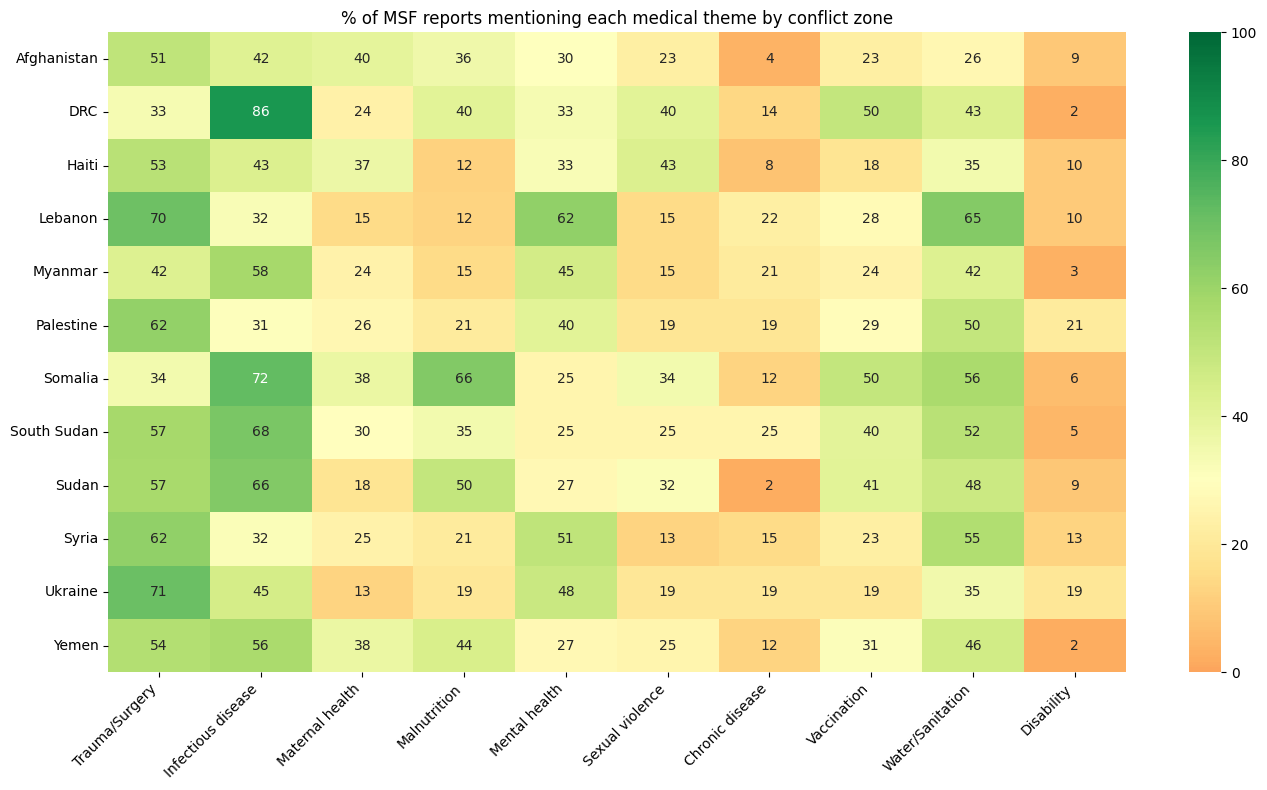

In [16]:
# Heatmap: themes x countries
hm = pd.DataFrame(index=sorted(df['country'].unique()))
for theme, kw in THEMES.items():
    pat = '|'.join(kw)
    for c in hm.index:
        t = df.loc[df['country']==c, 'clean'].str.lower()
        hm.loc[c, theme] = t.str.contains(pat).mean()*100 if len(t)>0 else 0
hm = hm.astype(float)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(hm, annot=True, fmt='.0f', cmap='RdYlGn', vmin=0, vmax=100, center=30, ax=ax)
ax.set_title('% of MSF reports mentioning each medical theme by conflict zone')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('parse_bias_by_country.png', dpi=150, bbox_inches='tight')
plt.show()

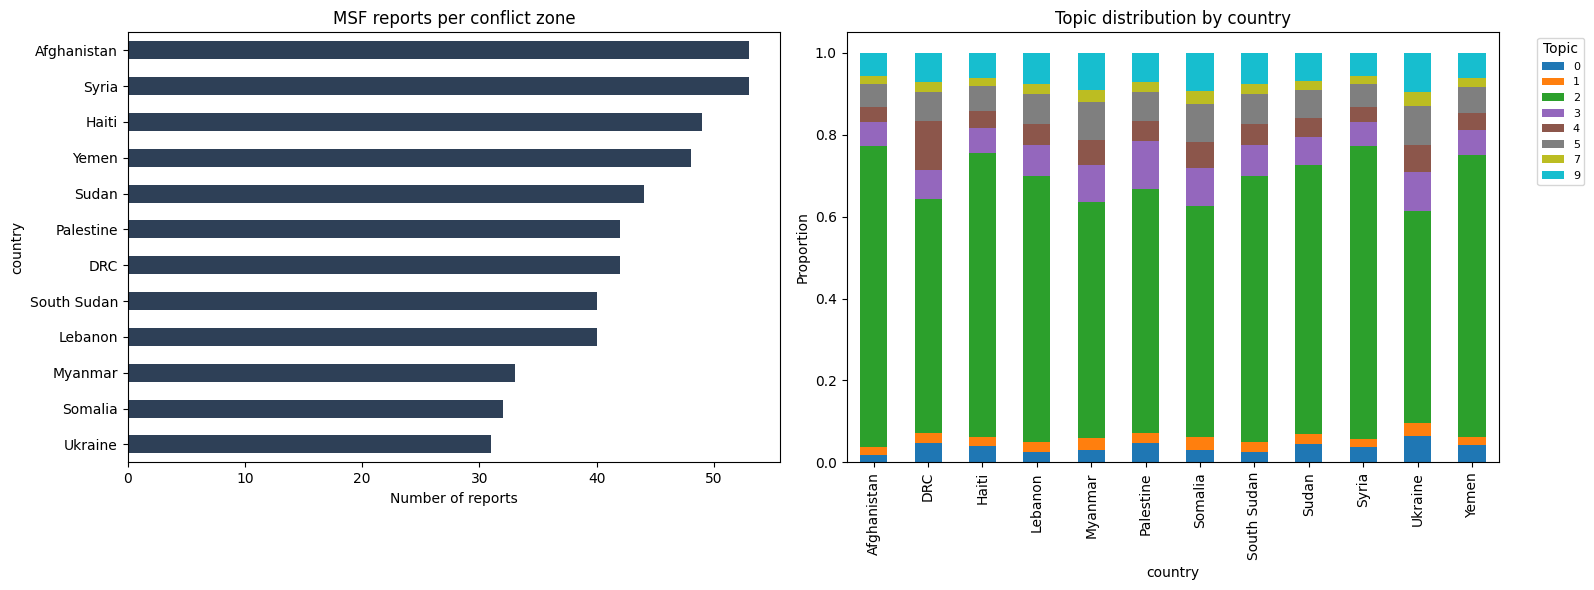

In [17]:
# Reports per country + topic breakdown
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df['country'].value_counts().plot.barh(ax=axes[0], color='#2E4057')
axes[0].set_xlabel('Number of reports')
axes[0].set_title('MSF reports per conflict zone')
axes[0].invert_yaxis()

pd.crosstab(df['country'], df['topic'], normalize='index').plot.bar(
    stacked=True, ax=axes[1], colormap='tab10')
axes[1].set_ylabel('Proportion')
axes[1].set_title('Topic distribution by country')
axes[1].legend(title='Topic', bbox_to_anchor=(1.05,1), fontsize=8)
plt.tight_layout()
plt.savefig('parse_overview.png', dpi=150, bbox_inches='tight')
plt.show()

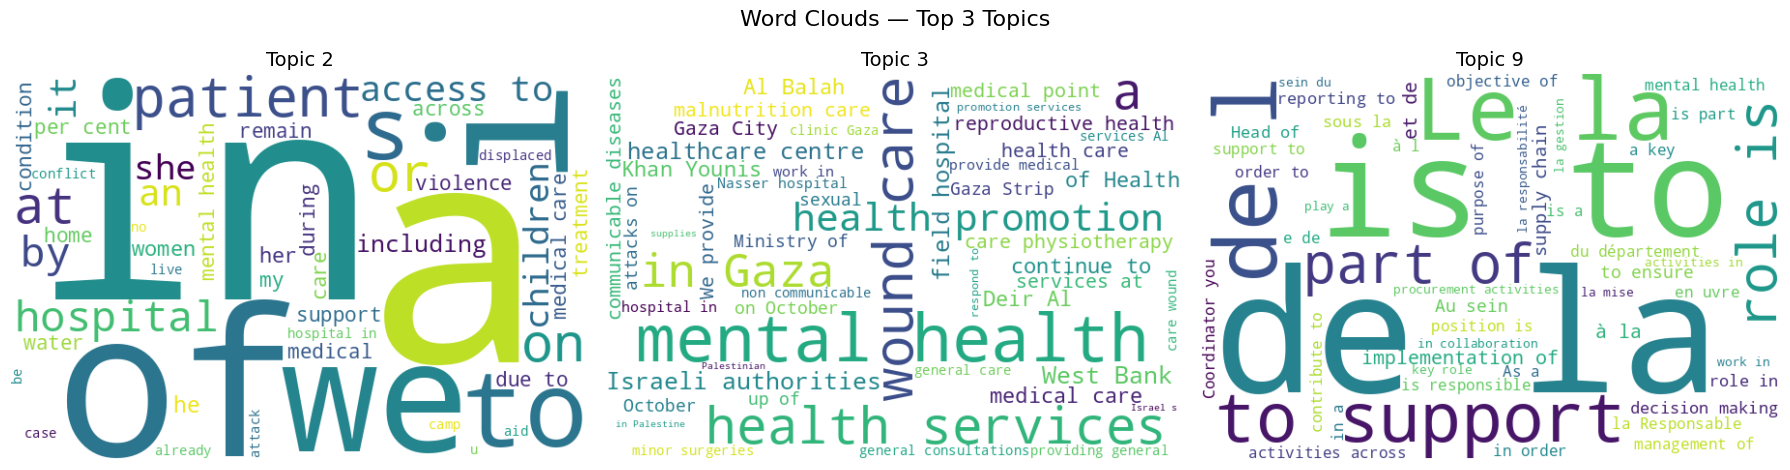

In [18]:
from wordcloud import WordCloud

top3 = df['topic'].value_counts().head(3).index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, tid in zip(axes, top3):
    text = ' '.join(df[df['topic']==tid]['clean'])
    wc = WordCloud(width=600, height=400, background_color='white',
                   max_words=50, stopwords=set(STOP), colormap='viridis').generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Topic {tid}', fontsize=14)
    ax.axis('off')
plt.suptitle('Word Clouds — Top 3 Topics', fontsize=16)
plt.tight_layout()
plt.savefig('parse_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

better idea is to add stop words

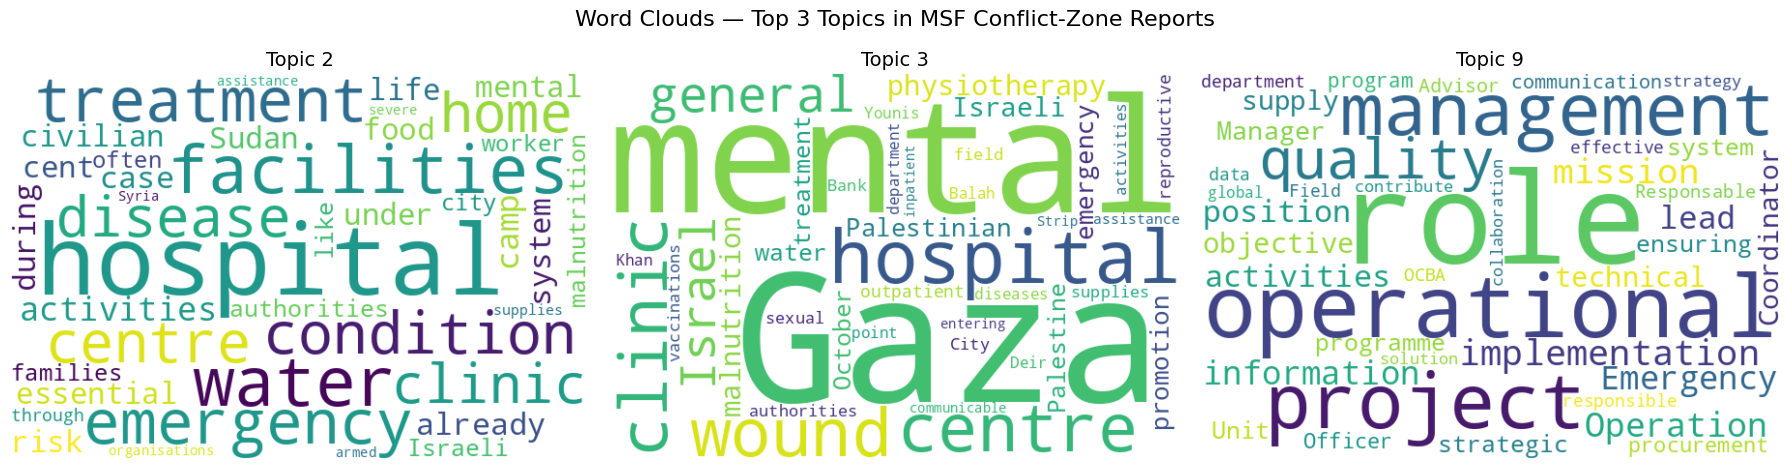

In [28]:
from wordcloud import WordCloud

STOP_ALL = set(STOP + [
    'said','says','told','added','noted','reported','explained','described',
    'need','needs','needed','provide','provides','provided','providing',
    'work','works','working','worked','support','supports','supporting',
    'supported','treat','treated','treating','receive','received','receiving',
    'include','includes','including','included','continue','continues',
    'continued','continuing','affect','affected','affecting','offer',
    'reach','reached','reaching','deliver','delivered','delivering',
    'ensure','face','faced','facing','remain','remains','remained',
    'increase','increased','increasing','force','forced','flee','fled',
    'fleeing','live','lives','living','make','made','making','take',
    'taken','taking','help','helped','helping','run','running',
    'come','coming','start','started','must','able','available',
    'caused','cause','due','see','seen','seeing','saw','left',
    'called','calling','call','access','displaced','displacement',
    'response','situation','conflict','crisis','violence','attacks',
    'communities','community','services','service','care','medical',
    'health','healthcare','children','women','men','patients',
    'across','several','months','month','week','weeks','last',
    'number','hundreds','thousands','part','areas','region',
    'state','states','north','south','east','west','central',
    'selon','dans','plus','pour','avec','sont','nous','cette',
    'leur','tout','comme','mais','entre','sans','aussi','depuis',
    'les','des','est','une','que','qui','par','sur','pas','ont',
])

top3 = df['topic'].value_counts().head(3).index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, tid in zip(axes, top3):
    text = ' '.join(df[df['topic'] == tid]['clean'])
    wc = WordCloud(
        width=600, height=400,
        background_color='white',
        max_words=40,
        stopwords=STOP_ALL,
        colormap='viridis',
        collocations=False,  # avoids repeating bigrams
        min_word_length=4,   # kills short junk
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Topic {tid}', fontsize=14)
    ax.axis('off')

plt.suptitle('Word Clouds — Top 3 Topics in MSF Conflict-Zone Reports', fontsize=16)
plt.tight_layout()
plt.savefig('parse_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
print('=' * 60)
print('PARSE Topic Modelling — Summary')
print('=' * 60)
print(f'Documents: {len(df)}')
print(f'Countries: {df["country"].nunique()}')
print(f'Topics: {df["topic"].nunique()}')
print()
print('Most reported:')
for _, r in tdf.sort_values('Pct', ascending=False).head(3).iterrows():
    print(f'  {r["Theme"]}: {r["Pct"]:.1f}%')
print()
print('Least reported (invisibility bias):')
for _, r in tdf.sort_values('Pct').head(3).iterrows():
    print(f'  {r["Theme"]}: {r["Pct"]:.1f}%')

PARSE Topic Modelling — Summary
Documents: 507
Countries: 12
Topics: 8

Most reported:
  Trauma/Surgery: 54.2%
  Infectious disease: 51.5%
  Water/Sanitation: 45.8%

Least reported (invisibility bias):
  Disability: 9.3%
  Chronic disease: 14.0%
  Sexual violence: 25.4%
